# 10. Optimización del umbral de decisión por segmento

En el notebook `09_model_evaluation_by_segment.ipynb` se identificó que el modelo tiene un
recall notablemente más bajo en sesiones de `Returning_Visitor` (64,3 %) frente a
`New_Visitor` (76,3 %), a pesar de que los visitantes recurrentes representan el 87 % del
tráfico del conjunto de prueba. Ese notebook recomendaba explorar umbrales de decisión
específicos por segmento como posible mitigación.

Este notebook responde directamente a esa recomendación: para cada tipo de visitante, se
busca el umbral que maximiza el F1 usando únicamente el conjunto de validación de ese
segmento, y se evalúa el efecto de usar ese umbral (en lugar del umbral global) sobre el
conjunto de prueba.

**Alcance y limitación:** al igual que en el notebook 09, se usa el candidato
`random_forest` (con `PageValues`) de `build_candidate_pipelines`, entrenado con el split
determinístico del equipo (`random_seed=42`), y no el modelo campeón CatBoost gestionado
por DVC. El propósito es evaluar la *estrategia* de umbral por segmento sobre el pipeline
disponible localmente; la conclusión sobre la dirección del trade-off (recall vs.
precisión) es trasladable al modelo campeón, aunque los valores exactos podrían variar.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from online_shoppers.data import load_dataset, TARGET_COLUMN
from online_shoppers.modeling import (
    split_dataset,
    build_candidate_pipelines,
    select_f1_threshold,
)

sns.set_theme(style='whitegrid')
BLUE = '#2563eb'
LIGHT_BLUE = '#93c5fd'

sessions = load_dataset('../data/raw/online_shoppers_intention.csv')
splits = split_dataset(sessions, random_seed=42)

pipelines = build_candidate_pipelines(include_page_values=True)
model = pipelines['random_forest']
model.fit(splits.train.drop(columns=[TARGET_COLUMN]), splits.train[TARGET_COLUMN])

val_probs = model.predict_proba(splits.validation.drop(columns=[TARGET_COLUMN]))[:, 1]
test_probs = model.predict_proba(splits.test.drop(columns=[TARGET_COLUMN]))[:, 1]

global_threshold = select_f1_threshold(splits.validation[TARGET_COLUMN], val_probs)
print(f'Umbral global (F1-óptimo en validación): {global_threshold:.4f}')

Umbral global (F1-óptimo en validación): 0.5043


## Umbral F1-óptimo por segmento

Se calcula el umbral que maximiza el F1 usando solo las sesiones de validación de cada
tipo de visitante. Un segmento se excluye de este cálculo si tiene menos de 30 sesiones
de validación o menos de 5 positivos (para evitar ajustar un umbral sobre una muestra
demasiado pequeña); en ese caso se mantiene el umbral global.

In [2]:
val_df = splits.validation.copy()
val_df['_prob'] = val_probs
test_df = splits.test.copy()
test_df['_prob'] = test_probs

segment_thresholds = {}
rows = []
for seg, group in val_df.groupby('VisitorType'):
    n = len(group)
    n_pos = int(group[TARGET_COLUMN].sum())
    if n >= 30 and n_pos >= 5:
        thr = select_f1_threshold(group[TARGET_COLUMN], group['_prob'])
        segment_thresholds[seg] = thr
        rows.append((seg, n, n_pos, round(thr, 4)))
    else:
        rows.append((seg, n, n_pos, f'muestra insuficiente -> usa umbral global ({global_threshold:.4f})'))

pd.DataFrame(rows, columns=['VisitorType', 'n_validacion', 'positivos_validacion', 'umbral_F1_optimo'])

,VisitorType,n_validacion,positivos_validacion,umbral_F1_optimo
0,New_Visitor,360,92,0.4238
1,Other,12,3,muestra insuficiente -> usa umbral global (0.5...
2,Returning_Visitor,2094,286,0.4442


## Efecto sobre el conjunto de prueba, por segmento

Para cada segmento se compara el desempeño usando el umbral global (0,5043, el que el
equipo usa actualmente) contra el umbral propio del segmento.

In [3]:
def metrics_for(y_true, y_pred):
    tp = int(((y_pred == 1) & (y_true == 1)).sum())
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    fn = int(((y_pred == 0) & (y_true == 1)).sum())
    tn = int(((y_pred == 0) & (y_true == 0)).sum())
    precision = tp / (tp + fp) if (tp + fp) > 0 else float('nan')
    recall = tp / (tp + fn) if (tp + fn) > 0 else float('nan')
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else float('nan')
    return dict(tp=tp, fp=fp, fn=fn, tn=tn, precision=precision, recall=recall, f1=f1)

records = []
for seg in val_df['VisitorType'].unique():
    seg_test = test_df[test_df['VisitorType'] == seg]
    if len(seg_test) == 0:
        continue
    y_true = seg_test[TARGET_COLUMN].values

    y_pred_global = (seg_test['_prob'].values >= global_threshold).astype(int)
    m_global = metrics_for(y_true, y_pred_global)
    records.append((seg, 'Umbral global', round(global_threshold, 4), len(seg_test),
                     int(y_true.sum()), m_global['precision'], m_global['recall'], m_global['f1']))

    thr = segment_thresholds.get(seg, global_threshold)
    y_pred_seg = (seg_test['_prob'].values >= thr).astype(int)
    m_seg = metrics_for(y_true, y_pred_seg)
    label = 'Umbral por segmento' if seg in segment_thresholds else 'Umbral por segmento (=global)'
    records.append((seg, label, round(thr, 4), len(seg_test),
                     int(y_true.sum()), m_seg['precision'], m_seg['recall'], m_seg['f1']))

comparison = pd.DataFrame(records, columns=[
    'VisitorType', 'estrategia', 'umbral', 'n_test', 'positivos_reales', 'precision', 'recall', 'f1'
])
comparison

,VisitorType,estrategia,umbral,n_test,positivos_reales,precision,recall,f1
0,Returning_Visitor,Umbral global,0.5043,2128,297,0.618123,0.643098,0.630363
1,Returning_Visitor,Umbral por segmento,0.4442,2128,297,0.566845,0.713805,0.631893
2,New_Visitor,Umbral global,0.5043,320,80,0.871429,0.762500,0.813333
3,New_Visitor,Umbral por segmento,0.4238,320,80,0.849315,0.775000,0.810458
4,Other,Umbral global,0.5043,18,5,1.000000,1.000000,1.000000
5,Other,Umbral por segmento (=global),0.5043,18,5,1.000000,1.000000,1.000000


## Efecto agregado: estrategia híbrida vs. umbral único

Se define una estrategia **híbrida**: aplicar el umbral propio a cada segmento con
muestra suficiente (`New_Visitor`, `Returning_Visitor`) y el umbral global al resto
(`Other`), y se compara contra usar el umbral global en todas las sesiones, sobre el
total del conjunto de prueba.

In [4]:
hybrid_pred = np.zeros(len(test_df), dtype=int)
for seg, thr in segment_thresholds.items():
    mask = (test_df['VisitorType'] == seg).values
    hybrid_pred[mask] = (test_df.loc[mask, '_prob'].values >= thr).astype(int)
mask_other = ~test_df['VisitorType'].isin(segment_thresholds.keys()).values
hybrid_pred[mask_other] = (test_df.loc[mask_other, '_prob'].values >= global_threshold).astype(int)

y_true_all = test_df[TARGET_COLUMN].values
y_pred_global_all = (test_df['_prob'].values >= global_threshold).astype(int)

m_global_all = metrics_for(y_true_all, y_pred_global_all)
m_hybrid_all = metrics_for(y_true_all, hybrid_pred)

overall = pd.DataFrame([
    {'estrategia': 'Umbral global (actual)', **m_global_all},
    {'estrategia': 'Híbrido por segmento (propuesto)', **m_hybrid_all},
])
overall

,estrategia,tp,fp,fn,tn,precision,recall,f1
0,Umbral global (actual),257,127,125,1957,0.669271,0.672775,0.671018
1,Híbrido por segmento (propuesto),279,173,103,1911,0.617257,0.730366,0.669065


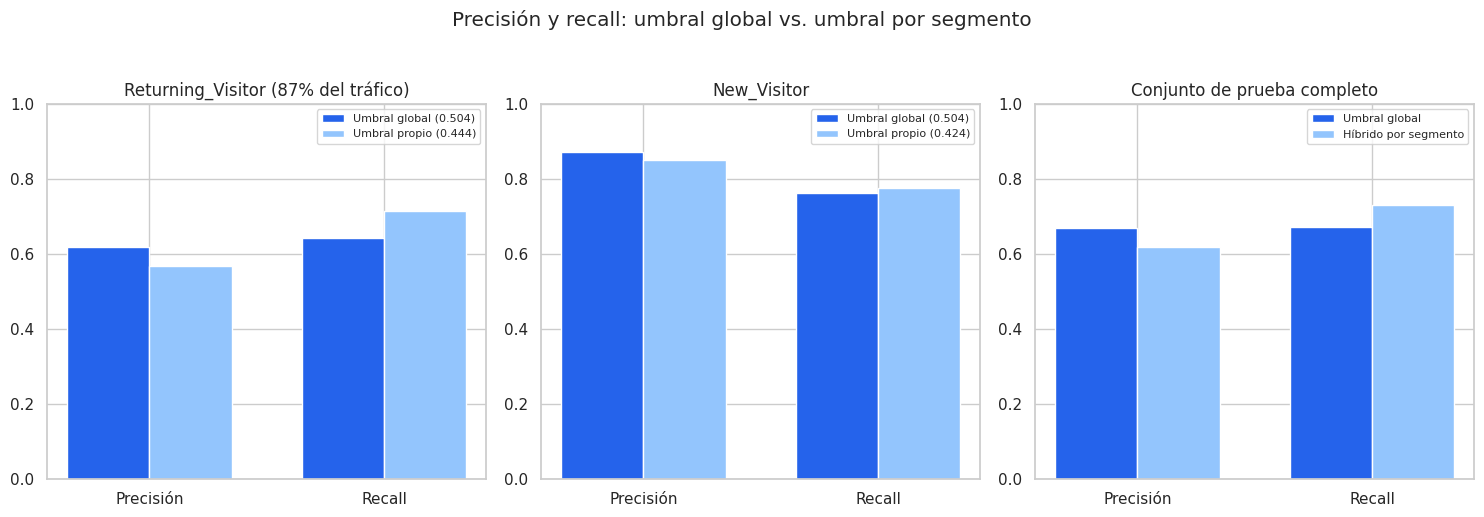

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

segments_to_plot = ['Returning_Visitor', 'New_Visitor']
titles = ['Returning_Visitor (87% del tráfico)', 'New_Visitor']

for ax, seg, title in zip(axes[:2], segments_to_plot, titles):
    sub = comparison[comparison['VisitorType'] == seg]
    global_row = sub[sub['estrategia'] == 'Umbral global'].iloc[0]
    seg_row = sub[sub['estrategia'].str.startswith('Umbral por segmento')].iloc[0]

    x = np.arange(2)
    width = 0.35
    ax.bar(x - width/2, [global_row['precision'], global_row['recall']], width,
           label=f"Umbral global ({global_row['umbral']:.3f})", color=BLUE)
    ax.bar(x + width/2, [seg_row['precision'], seg_row['recall']], width,
           label=f"Umbral propio ({seg_row['umbral']:.3f})", color=LIGHT_BLUE)
    ax.set_xticks(x)
    ax.set_xticklabels(['Precisión', 'Recall'])
    ax.set_ylim(0, 1)
    ax.set_title(title)
    ax.legend(fontsize=8)

ax = axes[2]
x = np.arange(2)
width = 0.35
ax.bar(x - width/2, [m_global_all['precision'], m_global_all['recall']], width,
       label='Umbral global', color=BLUE)
ax.bar(x + width/2, [m_hybrid_all['precision'], m_hybrid_all['recall']], width,
       label='Híbrido por segmento', color=LIGHT_BLUE)
ax.set_xticks(x)
ax.set_xticklabels(['Precisión', 'Recall'])
ax.set_ylim(0, 1)
ax.set_title('Conjunto de prueba completo')
ax.legend(fontsize=8)

fig.suptitle('Precisión y recall: umbral global vs. umbral por segmento', y=1.03)
fig.tight_layout()
fig.savefig('../reports/figures/threshold_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusión

Los umbrales F1-óptimos por segmento resultan **más bajos** que el umbral global
(0,4442 para `Returning_Visitor` y 0,4238 para `New_Visitor`, frente a 0,5043), lo que
indica que el modelo tiende a subestimar la probabilidad de compra en ambos segmentos
respecto al punto de corte que el equipo usa actualmente.

El efecto es más relevante en `Returning_Visitor`, el segmento dominante (87 % del
tráfico de prueba) y el más débil según el notebook 09: usar su umbral propio
(0,4442) en lugar del global eleva el recall de 64,3 % a 71,4 % (21 compradores reales
adicionales identificados, de 191 a 212 verdaderos positivos), a costa de bajar la
precisión de 61,8 % a 56,7 % (44 falsos positivos adicionales). El F1 se mantiene
prácticamente igual (0,630 vs. 0,632): no es una mejora "gratis", es un cambio en el
punto del trade-off precisión-recall. En `New_Visitor` el efecto es marginal (recall
76,2 % a 77,5 %), ya que el modelo ya funciona razonablemente bien en ese segmento.

Sobre el conjunto de prueba completo, la estrategia híbrida (umbral propio en los dos
segmentos con muestra suficiente, umbral global en el resto) sube el recall global de
67,3 % a 73,0 % (22 compradores reales adicionales detectados) y baja la precisión de
66,9 % a 61,7 % (46 falsos positivos adicionales); el F1 global se mantiene
prácticamente estable (0,671 vs. 0,669).

**Recomendación:** dado que el caso de negocio es identificar sesiones con mayor
probabilidad de compra (por ejemplo, para priorizar una acción comercial u oferta),
perder algunos falsos positivos suele ser menos costoso que dejar pasar compradores
reales sin detectar. Por eso se recomienda evaluar con el equipo de negocio si adoptar
el umbral específico para `Returning_Visitor` (0,4442) es preferible al umbral único
actual, en lugar de asumir que el umbral global es automáticamente el más adecuado para
el segmento mayoritario. En cualquier caso, esta decisión no debería tomarse solo con
F1 agregado, que aquí resulta insensible al cambio: debe evaluarse junto con el costo
relativo real de un falso positivo frente a un falso negativo para el negocio.